# 1. Environment Setup

In [1]:
import sys 
import subprocess
from importlib.util import find_spec


# Required packages
required_packages = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'datasets': 'datasets',
    'pyarrow': 'pyarrow',
    'sklearn': 'scikit-learn',
    'tqdm': 'tqdm',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
}

print("Checking and installing missing dependencies... \n")
missing = []
for module_name, package_name in required_packages.items():
    if find_spec(module_name) is None:
        missing.append(package_name)

if missing:
    print(f"Installing missing packages: {','.join(missing)}. \n")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
    print("Installation complete. \n")
else:
    print("All dependencies already installed.\n")

Checking and installing missing dependencies... 

All dependencies already installed.



In [2]:
# Import Core Libraries
import pandas as pd
import numpy as np
from datasets import load_dataset, Dataset
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA        

c:\Users\lithi\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# # GPU Detection
# try:
#     import torch
#     cuda_available = torch.cuda.is_available()
#     if cuda_available:
#         gpu_name = torch.cuda.get_device_name(0)
#         print(f"GPU Detected: {gpu_name}")
#         DEVICE = "CUDA"
#     else:
#         print("GPU not available. Using CPU")
#         DEVICE = "CPU"
# except ImportError:
#     print("PyTorch not installed. Using CPU for analysis.")
#     DEVICE = "CPU"

In [ ]:
DIR = "../data/processed/"
SOURCE_OF_TRUTH_FILE_PARQUET = os.path.join(DIR, "source_of_truth.parquet")
SAMPLED_PARQUET = os.path.join(DIR, "amazon_reviews_s10.parquet")
SAMPLED_CSV = os.path.join(DIR, "amazon_reviews_s10.csv")
SAMPLE_SIZE = 43_886_944 # Was not used due to network issues in streaming
RANDOM_STATE = 42

# 2. Load the Dataset

In [5]:
# CONFIGURATION
# SAMPLE_SIZE = 15_000_000 # Was not used due to network issues in streaming
# RANDOM_STATE = 42
REVIEWS_URL = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Electronics.jsonl"

print(f"Configuration:")
# print(f"  Sample Size: {SAMPLE_SIZE:,}")
print(f"  Random State: {RANDOM_STATE}")
print(f"  Source: Amazon Electronics Reviews (Hugging Face)\n")

Configuration:
  Random State: 42
  Source: Amazon Electronics Reviews (Hugging Face)



In [ ]:
# Load Dataset
# import itertools

# print(f"Loading {SAMPLE_SIZE:,} reviews from Amazon Electronics dataset...\n")

# ds_iter = load_dataset("json", data_files=REVIEWS_URL, split="train", streaming=True)
# sample = list(tqdm(itertools.islice(ds_iter, SAMPLE_SIZE), total=SAMPLE_SIZE, desc="Streaming"))

# df = Dataset.from_list(sample).to_pandas()

ds = load_dataset("json", data_files=REVIEWS_URL, split="train")
df = pd.DataFrame(ds) 

print(f"\nDataset loaded: {len(df):,} reviews.")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")

# 3. Quick Overview

In [ ]:
print("Shape of DataFrame:", df.shape)

Shape of DataFrame: (43886944, 10)


In [ ]:
print(f"Column Data Types:\n{df.dtypes}")

Column Data Types:
rating               float64
title                    str
text                     str
images                object
asin                     str
parent_asin              str
user_id                  str
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object


In [ ]:
missing = df.isnull().sum()

if missing.sum() == 0:
    print(" No missing detected!")
else:
    for col, count in missing[missing > 0].items():
        print(f"  {col}: {count:,} missing values. ({count/len(df)*100:.1f}%)")

 No missing detected!


In [ ]:
print("Dataset preview:")
df.head()

Dataset preview:


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,[{'small_image_url': 'https://m.media-amazon.c...,B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1658185117948,0,True
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1592678549731,0,True
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1523093017534,0,True
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,1290278495000,18,True
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,1676601581238,0,True


# 4. Visualization (Before Fundamental Cleaning)

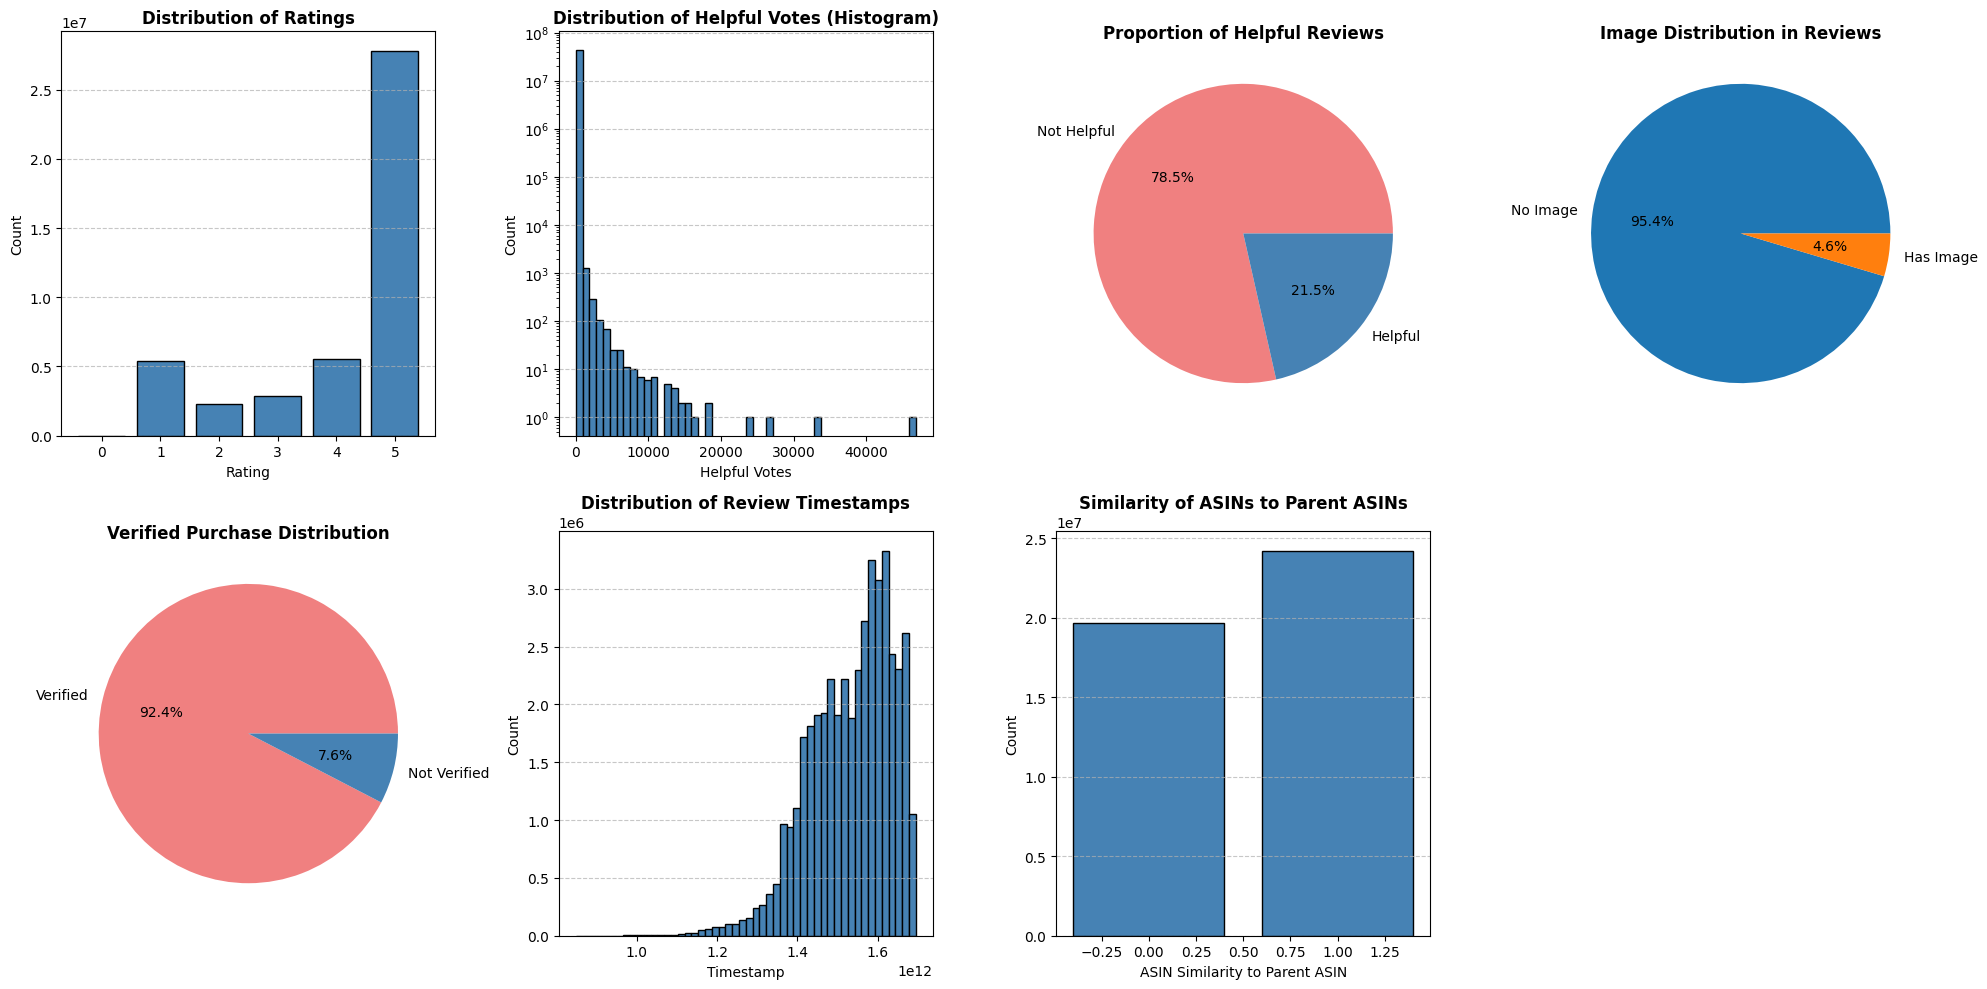

In [ ]:
# Section 4: All Visualizations Combined into Subplots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# 1. Rating Distribution
rating_counts = df['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Ratings', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].set_xticks(rating_counts.index)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 2. Helpful Votes Histogram
axes[1].hist(df['helpful_vote'], bins=50, color='steelblue', edgecolor='black')
axes[1].set_title('Distribution of Helpful Votes (Histogram)', fontweight='bold')
axes[1].set_xlabel('Helpful Votes')
axes[1].set_ylabel('Count')
axes[1].set_yscale('log')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# 3. Helpful Votes Pie Chart
is_helpful_review = df['helpful_vote'] > 0
counts = is_helpful_review.value_counts(sort=False).sort_index()
axes[2].pie(counts, labels=['Not Helpful', 'Helpful'], autopct='%1.1f%%', 
            colors=['lightcoral', 'steelblue'])
axes[2].set_title('Proportion of Helpful Reviews', fontweight='bold')

# 4. Image Distribution
has_image = df['images'].map(len).gt(0).value_counts()
axes[3].pie(has_image.values, 
            labels=['Has Image' if i else 'No Image' for i in has_image.index],
            autopct='%1.1f%%')
axes[3].set_title('Image Distribution in Reviews', fontweight='bold')

# 5. Verified Purchase Distribution
verified = df['verified_purchase'].value_counts()
axes[4].pie(verified.values, 
            labels=['Verified' if v else 'Not Verified' for v in verified.index],
            autopct='%1.1f%%', colors=['lightcoral', 'steelblue'])
axes[4].set_title('Verified Purchase Distribution', fontweight='bold')

# 6. Timestamp Distribution
axes[5].hist(df['timestamp'], bins=50, color='steelblue', edgecolor='black')
axes[5].set_title('Distribution of Review Timestamps', fontweight='bold')
axes[5].set_xlabel('Timestamp')
axes[5].set_ylabel('Count')
axes[5].grid(axis='y', linestyle='--', alpha=0.7)

# 7. ASIN Similarity
same_id = (df['asin'] == df['parent_asin']).value_counts().sort_index()
axes[6].bar(same_id.index, same_id.values, color='steelblue', edgecolor='black')
axes[6].set_xlabel('ASIN Similarity to Parent ASIN')
axes[6].set_ylabel('Count')
axes[6].set_title('Similarity of ASINs to Parent ASINs', fontweight='bold')
axes[6].grid(axis='y', linestyle='--', alpha=0.7)

# Hide the 8th empty subplot
axes[7].axis('off')

plt.tight_layout()
plt.show()

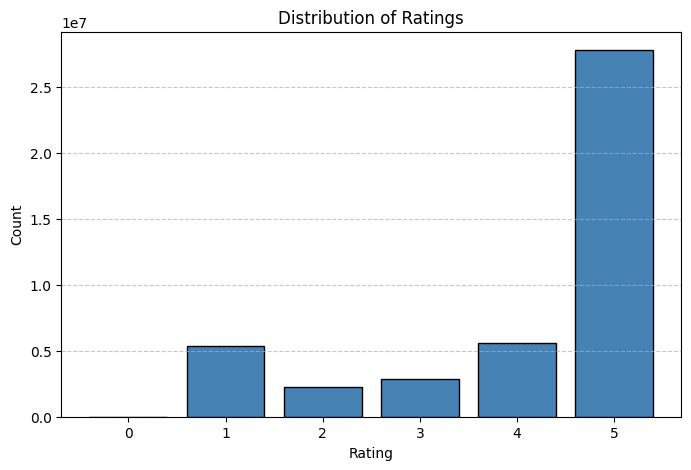


⭐ Rating Distribution:
  0.0:   0.0% 
  1.0:  12.2% ████
  2.0:   5.1% █
  3.0:   6.6% ██
  4.0:  12.7% ████
  5.0:  63.4% █████████████████████


In [ ]:
# Rating Distribution
rating_counts = df['rating'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='black')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rating_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"\n⭐ Rating Distribution:")
for rating in sorted(df['rating'].unique()):
    count = (df['rating'] == rating).sum()
    pct = count / len(df) * 100
    bar = '█' * int(pct / 3)
    print(f"  {rating}: {pct:5.1f}% {bar}")

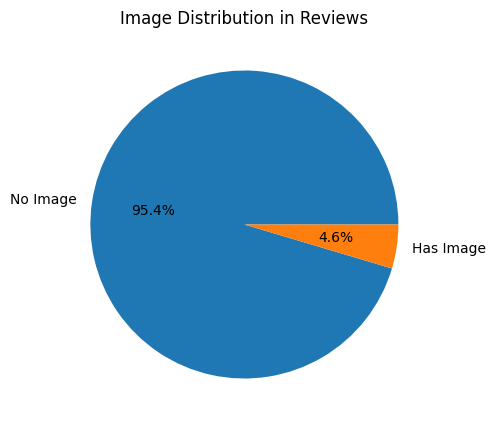


📸 Image Distribution:
  Has Image: 2,023,745 reviews (4.6%)
  No Image: 41,863,199 reviews (95.4%)


In [ ]:
# Image Distribution
plt.figure(figsize=(8,5))
has_image = df['images'].map(len).gt(0).value_counts()

plt.pie(
    has_image.values,
    labels=['Has Image' if i else 'No Image' for i in has_image.index],
    autopct='%1.1f%%'
)
plt.title('Image Distribution in Reviews')
plt.show()

image_counts = (
    df["images"]
    .astype(str)
    .apply(lambda x: x != "[]" and x != "nan")
    .value_counts()
)
print(f"\n📸 Image Distribution:")
print(f"  Has Image: {image_counts.get(True, 0):,} reviews ({image_counts.get(True, 0)/len(df)*100:.1f}%)")
print(f"  No Image: {image_counts.get(False, 0):,} reviews ({image_counts.get(False, 0)/len(df)*100:.1f}%)")

# 5. Check for Missing values 

In [ ]:
print("Basic Data Cleaning")

# Remove empty rows, using 'how=all' to drop rows where all the elements are missing
df = df.dropna(how='all')
print(f"  After dropping empty rows, dataset shape: {df.shape[0]:,} rows.")
print(f"  Total dropped rows: {SAMPLE_SIZE - df.shape[0]:,} ({(SAMPLE_SIZE - df.shape[0])/SAMPLE_SIZE*100:.1f}%)\n")


# Remove empty text
df = df[
    (df['text'].fillna('').str.strip().str.len() > 0) | 
    (df['title'].fillna('').str.strip().str.len() > 0)
]
print(f"  Non-Empty text or Non-Empty title, dataset shape: {df.shape[0]:,} rows.")


# Remove rows where 'text' is empty or only whitespace
print(f"  Non-empty text, dataset shape: {df[df['text'].notna() & (df['text'].str.strip().str.len() > 0)].shape[0]:,} rows.")


# Drop rows with missing text, helpful_vote, or rating
df = df.dropna(subset=["text", "helpful_vote", "rating"])
print(f"  After dropping rows with missing text, helpful_vote, or rating, dataset shape: {df.shape[0]:,} rows.")
print(f"  Total dropped rows: {df.shape[0] - df.shape[0]:,} ({(df.shape[0] - df.shape[0])/df.shape[0]*100:.1f}%)\n")

Basic Data Cleaning
  After dropping empty rows, dataset shape: 43,886,944 rows.
  Total dropped rows: -28,886,944 (-192.6%)

  Non-Empty text or Non-Empty title, dataset shape: 43,886,944 rows.
  Non-empty text, dataset shape: 43,845,751 rows.
  After dropping rows with missing text, helpful_vote, or rating, dataset shape: 43,886,944 rows.
  Total dropped rows: 0 (0.0%)



Save Raw Dataset --> To keep the raw data, if required later on

In [ ]:
df_save = df.copy()

# 6. Cleaning --> According to the problem statement

## 6.1 Filter Reviews with helpful votes

In [ ]:
df = df[df['helpful_vote'] > 0].copy()

print(f"  After filtering for helpful reviews, dataset shape: {df.shape[0]:,} rows.")
print(f"  Total dropped rows: {SAMPLE_SIZE - df.shape[0]:,} ({(SAMPLE_SIZE - df.shape[0])/SAMPLE_SIZE*100:.1f}%)\n")

  After filtering for helpful reviews, dataset shape: 9,421,755 rows.
  Total dropped rows: 5,578,245 (37.2%)



## 6.2 Dropping unncessary columns

**user_id**: Drop user_id because reviewer identity does not generalise to unseen users, risks data leakage and bias, and adds privacy-sensitive information with no predictive value for review helpfulness.

In [ ]:
df.drop(columns=['user_id'], inplace=True)

print(f"  After dropping 'user_id' column, dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")

  After dropping 'user_id' column, dataset shape: 9,421,755 x 9.


**asin**: Drop asin because it represents individual product variants (colour/size versions), which fragments the data and introduces artificial duplication, whereas parent_asin already groups all variants under the true product.

**parent_asin**: Keep parent_asin because it preserves product-level context needed for business insights, clustering, and later merchant recommendations.

In [ ]:
df.drop(columns=['asin'], inplace=True)

print(f"  After dropping 'asin' column, dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")

  After dropping 'asin' column, dataset shape: 9,421,755 x 8.


# 7. Reduce Memory Usage

In [ ]:
print(f"Before dtype conversion\n{df.dtypes}")

Before dtype conversion
rating               float64
title                    str
text                     str
images                object
parent_asin              str
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object


In [ ]:
# Conversion of data types to optimize memory usage
dtype_mapping = {
    'rating': 'int8',
    'parent_asin': 'category',
    'helpful_vote': 'int32',
    'verified_purchase': 'bool',
}

before_mem = df.memory_usage(deep=True).sum() / 1024**2
df = df.astype(dtype_mapping)
after_mem = df.memory_usage(deep=True).sum() / 1024**2

print(f"\nMemory Usage Optimization:")
print(f"  Before optimization, memory usage: {before_mem:.2f} MB")
print(f"  After optimization, memory usage: {after_mem:.2f} MB")

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
print(f"  After converting 'timestamp' to datetime, dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")


Memory Usage Optimization:
  Before optimization, memory usage: 5933.25 MB
  After optimization, memory usage: 5721.79 MB
  After converting 'timestamp' to datetime, dataset shape: 9,421,755 x 8.


In [ ]:
print(f"After dtype conversion\n{df.dtypes}")

After dtype conversion
rating                         int8
title                           str
text                            str
images                       object
parent_asin                category
timestamp            datetime64[ms]
helpful_vote                  int32
verified_purchase              bool
dtype: object


# 8. Feature Engineeering 

## 8.1 Merge 'text' and 'title' columns

In [ ]:
# Combining text + title into single column, as some of the text are empty but title is not, and vice versa
# df['review_text'] = df
review_text = (df['title'].fillna("").str.strip() + " " + df["text"].fillna("").str.strip()).str.strip()
print(review_text.head()) 

df['review_text'] = review_text

# Check again for any empty review_text after combining
df = df[df["review_text"].str.len() > 0]
print(f"  After combining text and title, dataset shape: {df.shape[0]:,} rows.")

3     Great laptop backpack! I was searching for a s...
7     Love the headphones - great range These are fa...
12    legit legit.  love them.  I play with 1 in ful...
37    Does what it is meant to do Very easy to confi...
40    Protects my power supply from small screws Any...
dtype: str
  After combining text and title, dataset shape: 9,421,755 rows.


In [ ]:
# Drop original 'text' and 'title' columns as they are now redundant
df.drop(columns=['text', 'title'], inplace=True)

print(f"  After dropping 'text' and 'title' columns, dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")

  After dropping 'text' and 'title' columns, dataset shape: 9,421,755 x 7.


## 8.2 Create new feature


| Feature | Description | Data Type |
|---|---|---|
| `review_length` | (NF) Length of review text measured in characters (proxy for textual detail) | int64 |
| `is_verified` | (NF) Indicates whether the review comes from a verified purchase | int8 |
| `image_count` | (NF) Number of images attached to the review | int16 |
| `has_image` | (NF) Binary indicator showing whether the review contains at least one image | bool |
| `days_since_first_review` | (NF) Number of days elapsed since the earliest review in the dataset (temporal normalization feature) | int32 |
| `product_popularity` | (NF) Total number of reviews associated with the product (ASIN-level activity proxy) | int32 |

In [ ]:
# Create a feature for review length (number of characters) for clustering
df['review_length'] = df['review_text'].str.len().fillna(0).astype('int32')
print(f"  After adding 'review_length' column, dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")


# Convert 'verified_purchase' to int8 for clustering --> 0/1
df['is_verified'] = df['verified_purchase'].astype('int8')
if 'verified_purchase' in df.columns:
    df.drop(columns=['verified_purchase'], inplace=True)
print(f"  After converting 'verified_purchase' to 'is_verified', dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")


# Create number of images and has_image features for clustering
df['image_count'] = df['images'].apply(
    lambda x: len(x) if isinstance(x, list) else 0
).astype('int16')

df['has_image'] = (df['image_count'] > 0).astype('bool')
print(f"  After adding 'image_count' and 'has_image' columns, dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")


# Extract day of week and whether it's a weekend for clustering
df['day_of_week'] = df['timestamp'].dt.dayofweek.astype('int8')   # 0=Mon
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype('bool')

# Create a feature for how many days since the first review in the dataset, to capture temporal trends
first_review_date = df['timestamp'].min()
df['days_since_first_review'] = (
    (df['timestamp'] - first_review_date).dt.days
    .fillna(0)
    .astype('int32')
)
print(f"  After adding temporal features, dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")


# Create a feature for product popularity based on the number of reviews for each parent_asin
df['product_popularity'] = (
    df.groupby('parent_asin')['parent_asin']
    .transform('count')
    .astype('int32')
)

print(f"  After adding 'product_popularity' column, dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")

  After adding 'review_length' column, dataset shape: 9,421,755 x 8.
  After converting 'verified_purchase' to 'is_verified', dataset shape: 9,421,755 x 8.
  After adding 'image_count' and 'has_image' columns, dataset shape: 9,421,755 x 10.
  After adding temporal features, dataset shape: 9,421,755 x 13.
  After adding 'product_popularity' column, dataset shape: 9,421,755 x 14.


In [ ]:
df.head(2)

,rating,images,parent_asin,timestamp,helpful_vote,review_text,review_length,is_verified,image_count,has_image,day_of_week,is_weekend,days_since_first_review,product_popularity
3,5,[],B001OC5JKY,2010-11-20 18:41:35.000,18,Great laptop backpack! I was searching for a s...,1112,1,0,False,5,True,5115,89
7,5,[],B09S6Y5BRG,2018-11-04 18:40:31.659,9,Love the headphones - great range These are fa...,1082,1,0,False,6,True,8021,418


In [ ]:
df.dtypes

rating                               int8
images                             object
parent_asin                      category
timestamp                  datetime64[ms]
helpful_vote                        int32
review_text                           str
review_length                       int32
is_verified                          int8
image_count                         int16
has_image                            bool
day_of_week                          int8
is_weekend                           bool
days_since_first_review             int32
product_popularity                  int32
dtype: object

## 8.3 Save Source of Truth

In [ ]:
# Create directory if it doesn't exist
os.makedirs(DIR, exist_ok=True)

# Export the dataset
df.to_parquet(SOURCE_OF_TRUTH_FILE_PARQUET, index=False, engine="pyarrow")
print(f"Source of truth dataset exported to '{SOURCE_OF_TRUTH_FILE_PARQUET}'")

Source of truth dataset exported to '../data/processed/source_of_truth_15M.parquet'
